# Bank Loan Analysis - EDA

Same flow as the transactions notebook - import, check types, clean up the money/percent columns (they came in as text with $ and % signs), then explore.

In [1]:
# usual imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,5)
pd.set_option('display.max_columns', None)

In [ ]:
# file has some non-utf8 bytes in it, latin1 reads it fine
df = pd.read_csv('E:\bank-loan-analysis.csv', encoding='latin1')
df.shape

(38576, 31)

In [3]:
df.head()

        id address_state application_type emp_length              emp_title  \
0  1077430            GA       INDIVIDUAL   < 1 year                  Ryder   
1  1072053            CA       INDIVIDUAL    9 years         MKC Accounting   
2  1069243            CA       INDIVIDUAL    4 years  Chemat Technology Inc   
3  1041756            TX       INDIVIDUAL   < 1 year    barnes distribution   
4  1068350            IL       INDIVIDUAL  10+ years          J&J Steel Inc   

  grade home_ownership  issue_date last_credit_pull_date last_payment_date  \
0     C           RENT  02/11/2021            09/13/2021        04/13/2021   
1     E           RENT  01/01/2021            12/14/2021        01/15/2021   
2     C           RENT  01/05/2021            12/12/2021        01/09/2021   
3     B       MORTGAGE  02/25/2021            12/12/2021        03/12/2021   
4     A       MORTGAGE  01/01/2021            12/14/2021        01/15/2021   

   loan_status next_payment_date  member_id purpose sub_

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  str    
 2   application_type       38576 non-null  str    
 3   emp_length             38576 non-null  str    
 4   emp_title              38576 non-null  str    
 5   grade                  38576 non-null  str    
 6   home_ownership         38576 non-null  str    
 7   issue_date             38576 non-null  str    
 8   last_credit_pull_date  38576 non-null  str    
 9   last_payment_date      38576 non-null  str    
 10  loan_status            38576 non-null  str    
 11  next_payment_date      38576 non-null  str    
 12  member_id              38576 non-null  int64  
 13  purpose                38576 non-null  str    
 14  sub_grade              38576 non-null  str    
 15  term         

In [5]:
# nothing missing, good sign the excel/sql cleanup already handled it
df.isnull().sum()

id                       0
address_state            0
application_type         0
emp_length               0
emp_title                0
grade                    0
home_ownership           0
issue_date               0
last_credit_pull_date    0
last_payment_date        0
loan_status              0
next_payment_date        0
member_id                0
purpose                  0
sub_grade                0
term                     0
verification_status      0
annual_income            0
dti                      0
installment              0
int_rate                 0
loan_amount              0
total_acc                0
total_payment            0
loan_category            0
issue_month              0
issue_month_name         0
issue_year               0
repayment_ratio          0
income_band              0
dti_band                 0
dtype: int64

In [6]:
# checking for repeat loan ids just in case
df.duplicated().sum(), df['id'].duplicated().sum()

(np.int64(0), np.int64(0))

## Fixing dtypes

money columns came in as strings like "$30,000" and percents like "15.27%" - stripping the symbols and casting to float. dates are also text, converting those too.

In [7]:
money_cols = ['annual_income','installment','loan_amount','total_payment']
for c in money_cols:
    df[c] = df[c].replace('[\$,]', '', regex=True).astype(float)

pct_cols = ['dti','int_rate']
for c in pct_cols:
    df[c] = df[c].replace('%', '', regex=True).astype(float)

date_cols = ['issue_date','last_credit_pull_date','last_payment_date','next_payment_date']
for c in date_cols:
    df[c] = pd.to_datetime(df[c], format='%m/%d/%Y', errors='coerce')

df.dtypes

id                                int64
address_state                       str
application_type                    str
emp_length                          str
emp_title                           str
grade                               str
home_ownership                      str
issue_date               datetime64[us]
last_credit_pull_date    datetime64[us]
last_payment_date        datetime64[us]
loan_status                         str
next_payment_date        datetime64[us]
member_id                         int64
purpose                             str
sub_grade                           str
term                                str
verification_status                 str
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                     float64
total_acc                         int64
total_payment                   float64
loan_category                       str


In [8]:
# sanity check the conversion actually worked
df[['annual_income','installment','loan_amount','total_payment','dti','int_rate']].describe()

       annual_income   installment   loan_amount  total_payment           dti  \
count   3.857600e+04  38576.000000  38576.000000   38576.000000  38576.000000   
mean    6.964454e+04    326.872148  11296.066855   12263.348533     13.327433   
std     6.429368e+04    209.089372   7460.746022    9051.104777      6.666155   
min     4.000000e+03     16.000000    500.000000      34.000000      0.000000   
25%     4.150000e+04    168.000000   5500.000000    5633.000000      8.210000   
50%     6.000000e+04    283.000000  10000.000000   10042.000000     13.420000   
75%     8.320050e+04    434.250000  15000.000000   16658.000000     18.590000   
max     6.000000e+06   1305.000000  35000.000000   58564.000000     29.990000   

           int_rate  
count  38576.000000  
mean      12.048831  
std        3.716412  
min        5.420000  
25%        9.320000  
50%       11.860000  
75%       14.590000  
max       24.590000  

## Categorical columns
grade, status, purpose, ownership - the stuff that segments the loans

In [9]:
df['loan_status'].value_counts()

loan_status
Fully Paid     32145
Charged Off     5333
Current         1098
Name: count, dtype: int64

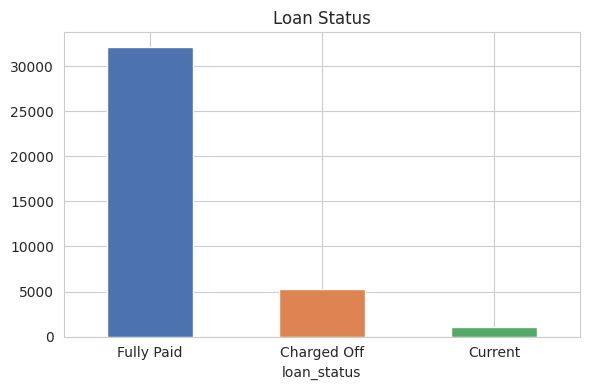

In [10]:
fig, ax = plt.subplots(figsize=(6,4))
df['loan_status'].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452','#55A868'], ax=ax)
ax.set_title('Loan Status')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

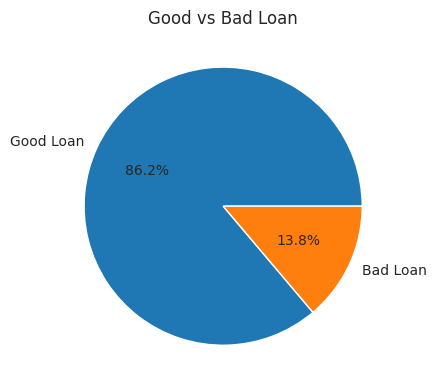

In [11]:
fig, ax = plt.subplots(figsize=(6,4))
df['loan_category'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax, ylabel='')
ax.set_title('Good vs Bad Loan')
plt.tight_layout()
plt.show()

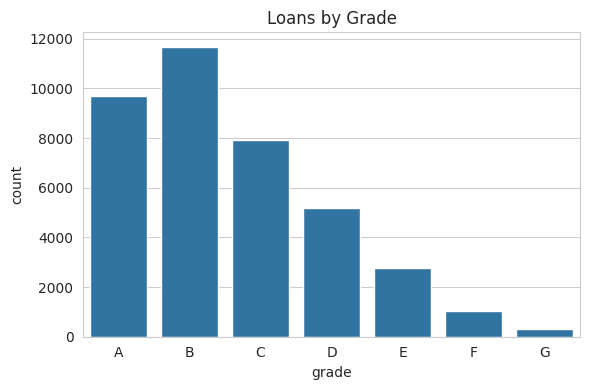

In [12]:
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(x='grade', data=df, order=sorted(df['grade'].unique()), ax=ax)
ax.set_title('Loans by Grade')
plt.tight_layout()
plt.show()

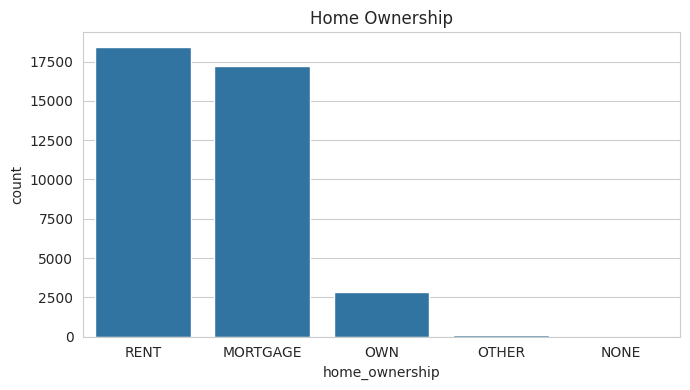

In [13]:
fig, ax = plt.subplots(figsize=(7,4))
sns.countplot(x='home_ownership', data=df, order=df['home_ownership'].value_counts().index, ax=ax)
ax.set_title('Home Ownership')
plt.tight_layout()
plt.show()

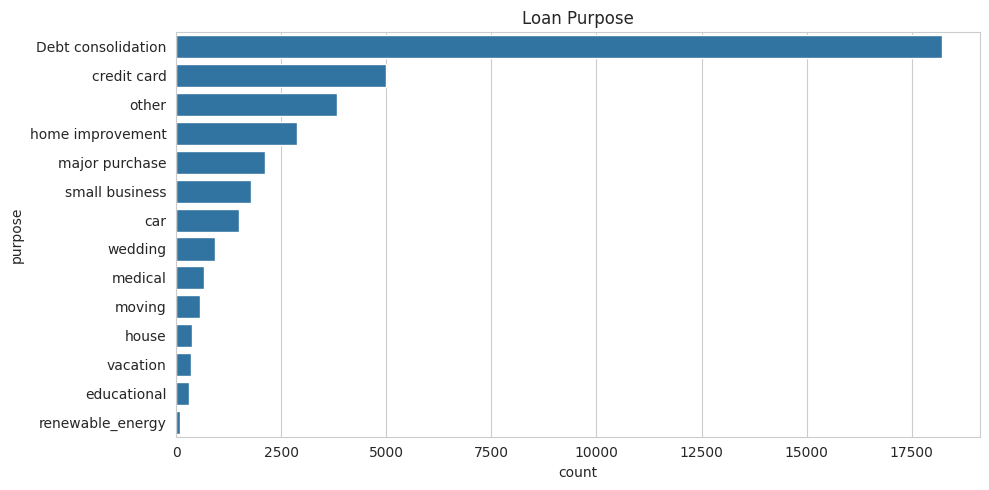

In [14]:
fig, ax = plt.subplots(figsize=(10,5))
sns.countplot(y='purpose', data=df, order=df['purpose'].value_counts().index, ax=ax)
ax.set_title('Loan Purpose')
plt.tight_layout()
plt.show()

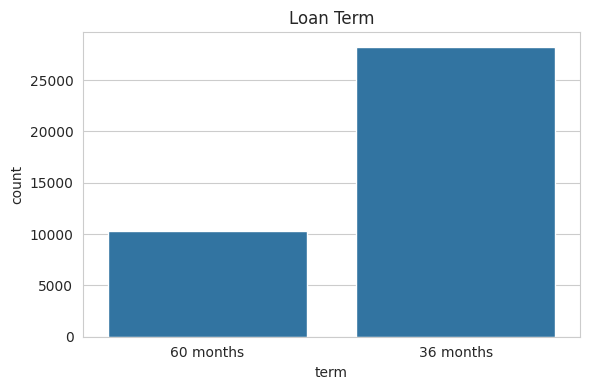

In [15]:
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(x='term', data=df, ax=ax)
ax.set_title('Loan Term')
plt.tight_layout()
plt.show()

## Numeric distributions
loan amount, interest rate, income, dti - where most loans actually sit

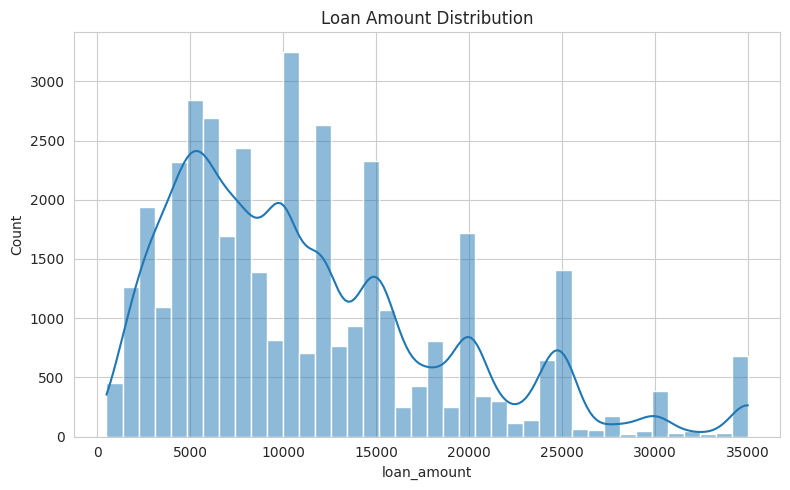

In [16]:
fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(df['loan_amount'], bins=40, kde=True, ax=ax)
ax.set_title('Loan Amount Distribution')
plt.tight_layout()
plt.show()

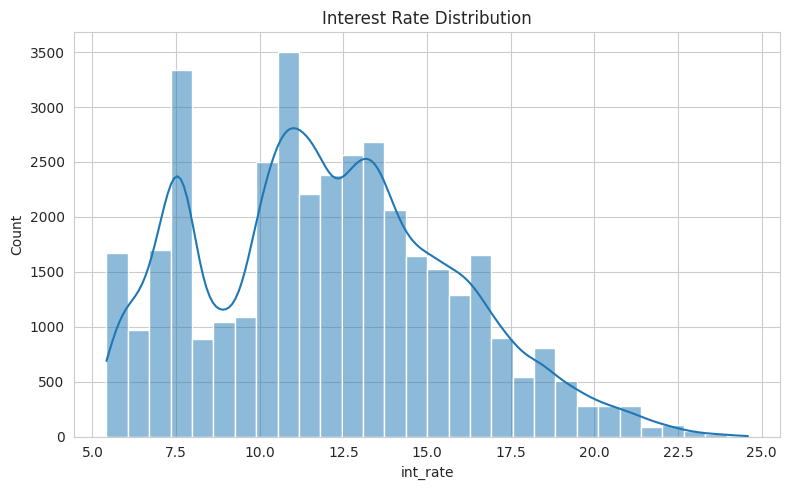

In [17]:
fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(df['int_rate'], bins=30, kde=True, ax=ax)
ax.set_title('Interest Rate Distribution')
plt.tight_layout()
plt.show()

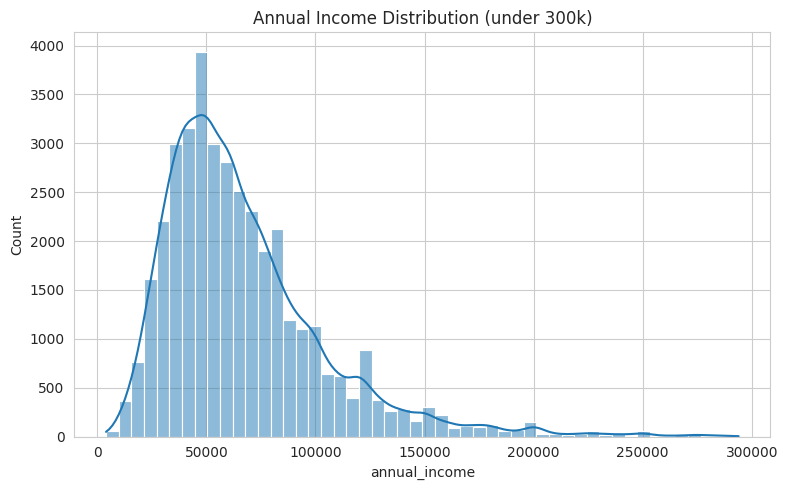

In [18]:
# income has a long tail, capping the x-axis view so the chart isn't useless
fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(df[df['annual_income'] < 300000]['annual_income'], bins=50, kde=True, ax=ax)
ax.set_title('Annual Income Distribution (under 300k)')
plt.tight_layout()
plt.show()

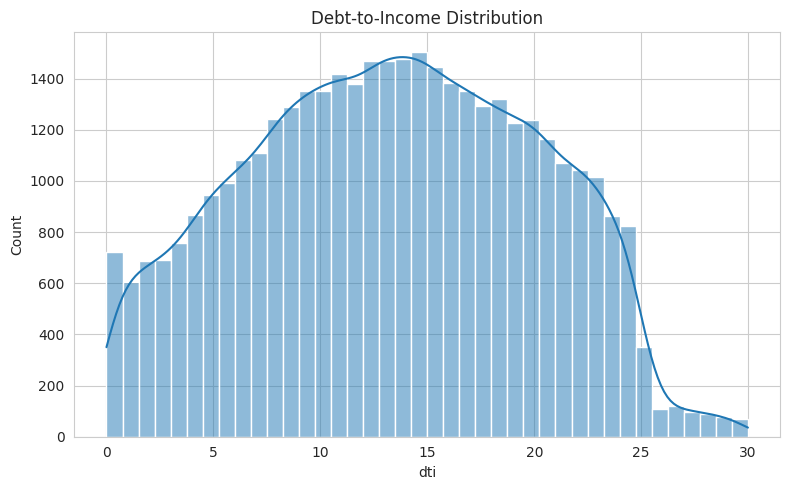

In [19]:
fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(df['dti'], bins=40, kde=True, ax=ax)
ax.set_title('Debt-to-Income Distribution')
plt.tight_layout()
plt.show()

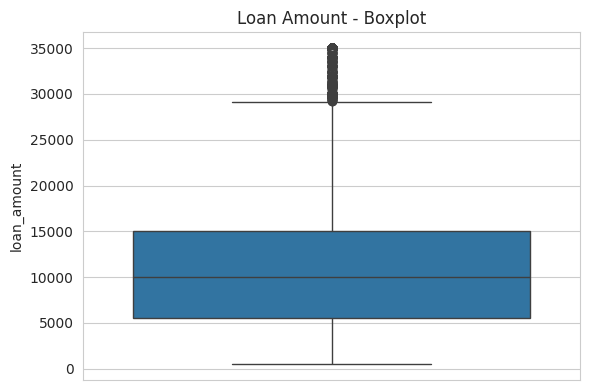

In [20]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(y=df['loan_amount'], ax=ax)
ax.set_title('Loan Amount - Boxplot')
plt.tight_layout()
plt.show()

## Rate and amount vs grade/purpose
grade is supposed to price risk, so int_rate should climb as grade gets worse - checking that holds

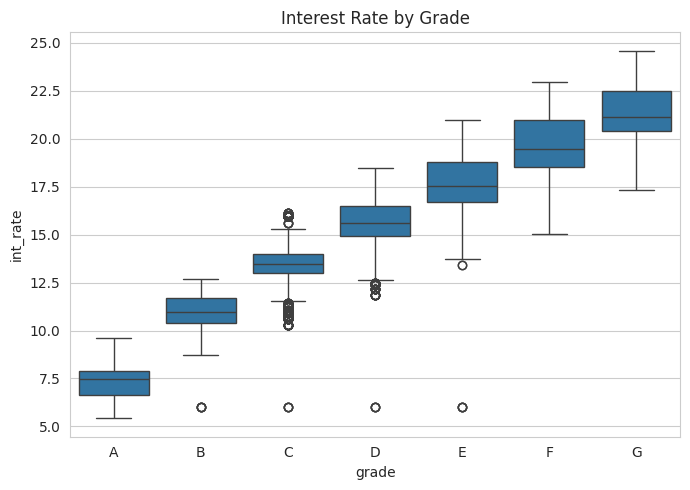

In [21]:
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(x='grade', y='int_rate', data=df, order=sorted(df['grade'].unique()), ax=ax)
ax.set_title('Interest Rate by Grade')
plt.tight_layout()
plt.show()

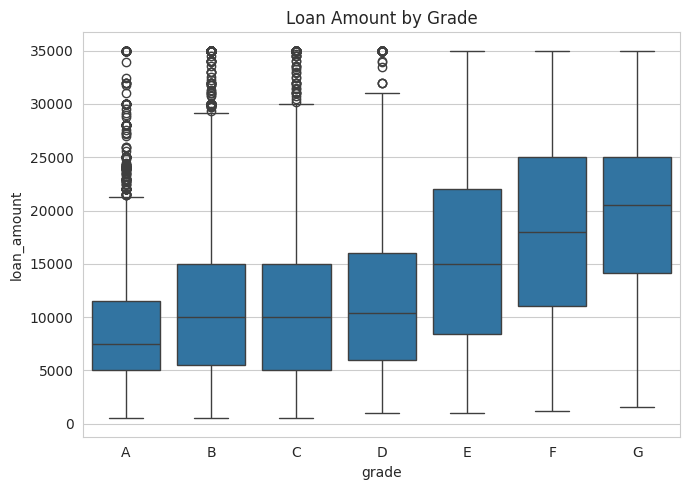

In [22]:
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(x='grade', y='loan_amount', data=df, order=sorted(df['grade'].unique()), ax=ax)
ax.set_title('Loan Amount by Grade')
plt.tight_layout()
plt.show()

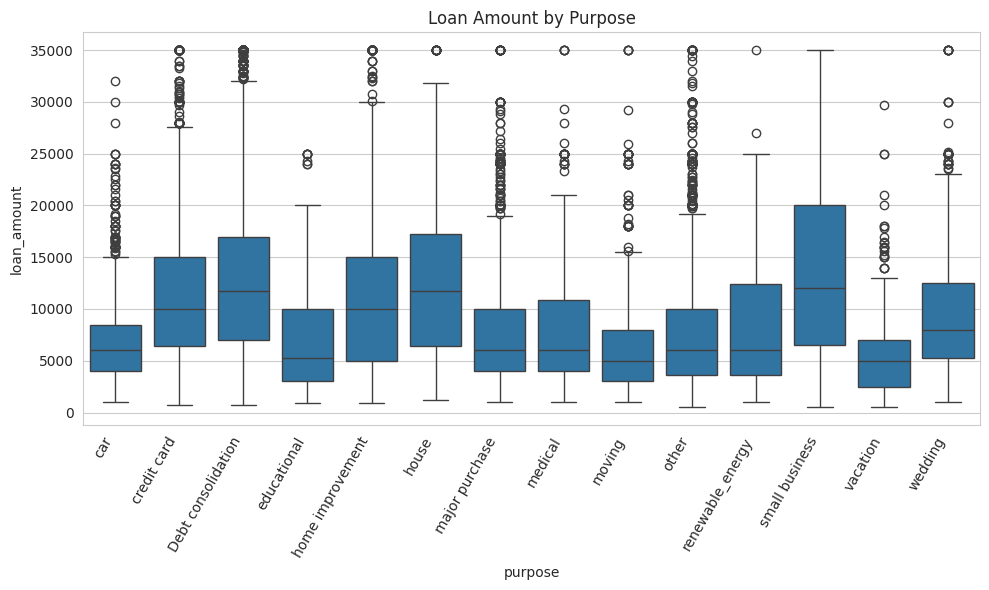

In [23]:
fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(x='purpose', y='loan_amount', data=df, ax=ax)
ax.set_title('Loan Amount by Purpose')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

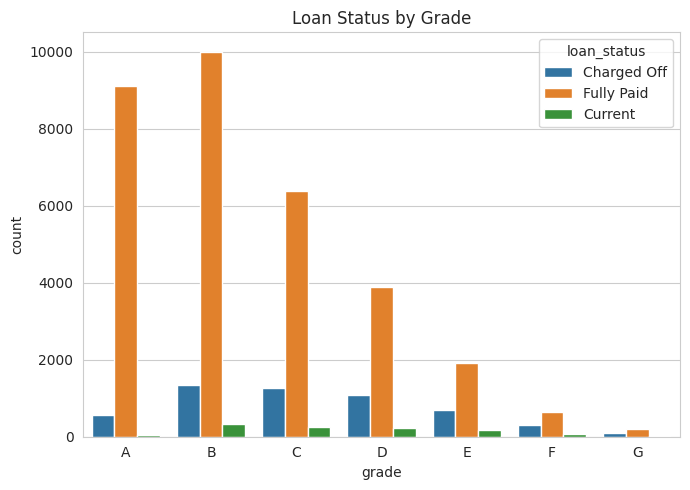

In [24]:
fig, ax = plt.subplots(figsize=(7,5))
sns.countplot(x='grade', hue='loan_status', data=df, order=sorted(df['grade'].unique()), ax=ax)
ax.set_title('Loan Status by Grade')
plt.tight_layout()
plt.show()

## Correlation
seeing which numeric fields actually move together before reading too much into any of it

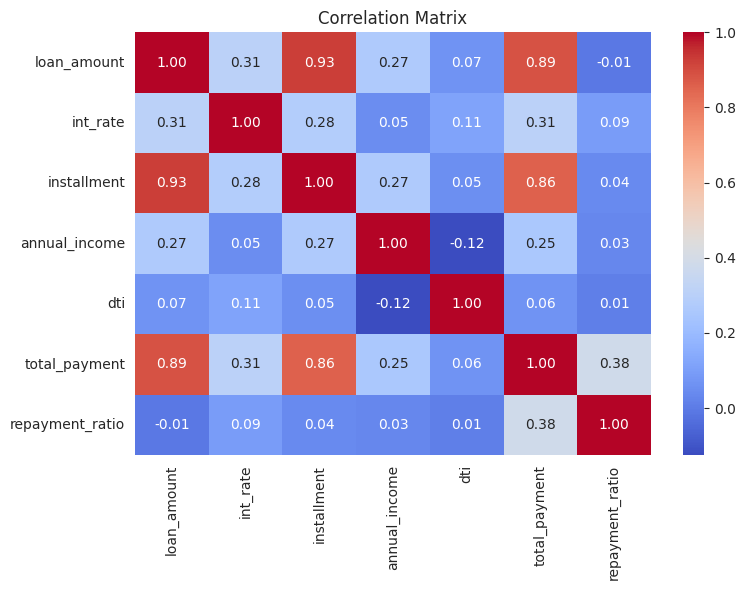

In [25]:
corr_cols = ['loan_amount','int_rate','installment','annual_income','dti','total_payment','repayment_ratio']
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

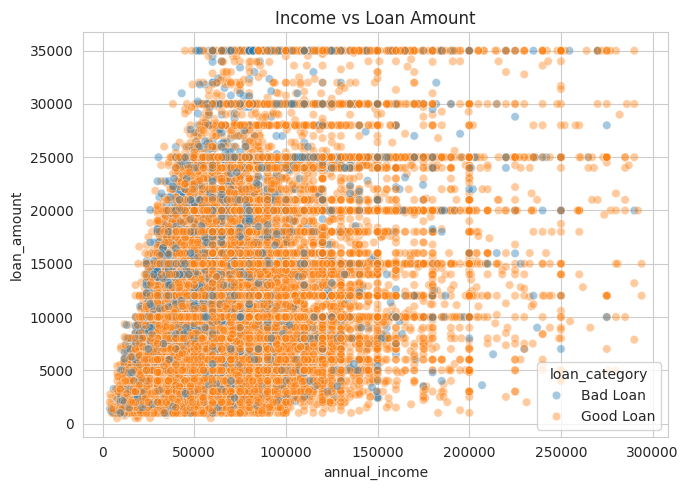

In [26]:
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(x='annual_income', y='loan_amount', hue='loan_category', data=df[df['annual_income']<300000], alpha=0.4, ax=ax)
ax.set_title('Income vs Loan Amount')
plt.tight_layout()
plt.show()

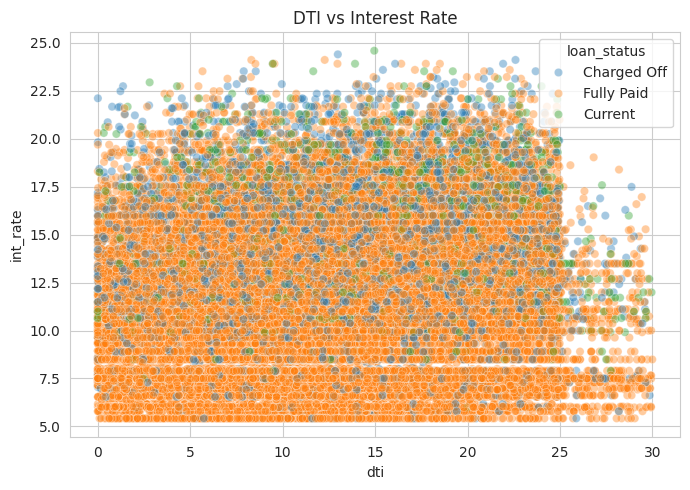

In [27]:
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(x='dti', y='int_rate', hue='loan_status', data=df, alpha=0.4, ax=ax)
ax.set_title('DTI vs Interest Rate')
plt.tight_layout()
plt.show()

## Time based
issue year is basically all 2021 here, so looking at month instead to see if there's any seasonality

In [28]:
df['issue_year'].value_counts()

issue_year
2021    38576
Name: count, dtype: int64

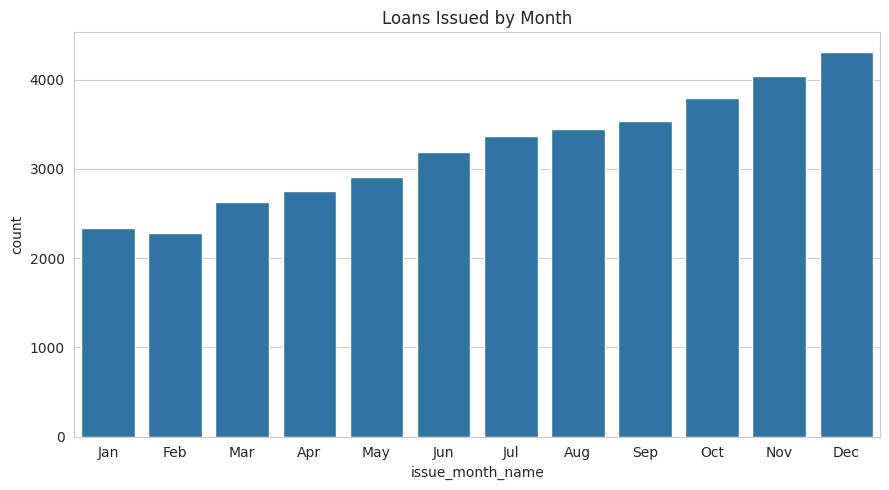

In [29]:
order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig, ax = plt.subplots(figsize=(9,5))
sns.countplot(x='issue_month_name', data=df, order=[m for m in order if m in df['issue_month_name'].unique()], ax=ax)
ax.set_title('Loans Issued by Month')
plt.tight_layout()
plt.show()

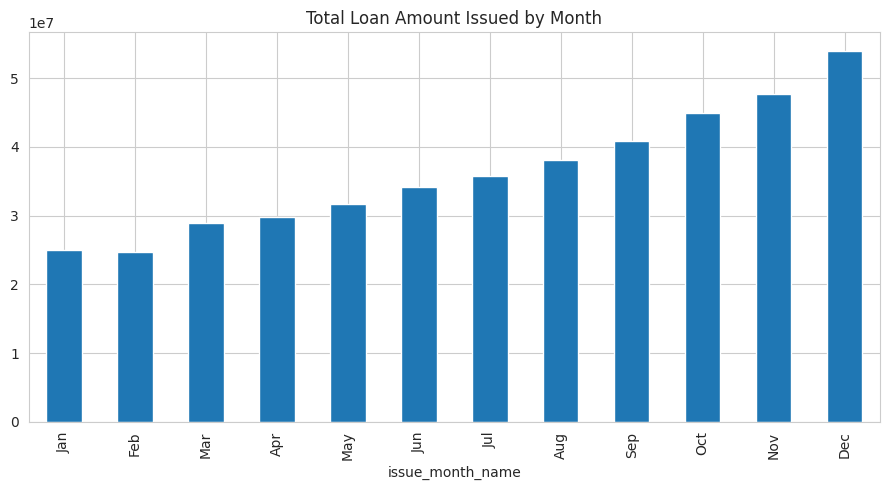

In [30]:
monthly_amt = df.groupby('issue_month_name')['loan_amount'].sum().reindex([m for m in order if m in df['issue_month_name'].unique()])
fig, ax = plt.subplots(figsize=(9,5))
monthly_amt.plot(kind='bar', ax=ax)
ax.set_title('Total Loan Amount Issued by Month')
plt.tight_layout()
plt.show()

## Income and dti bands
these bucket columns were already built during cleaning, just checking how loans spread across them

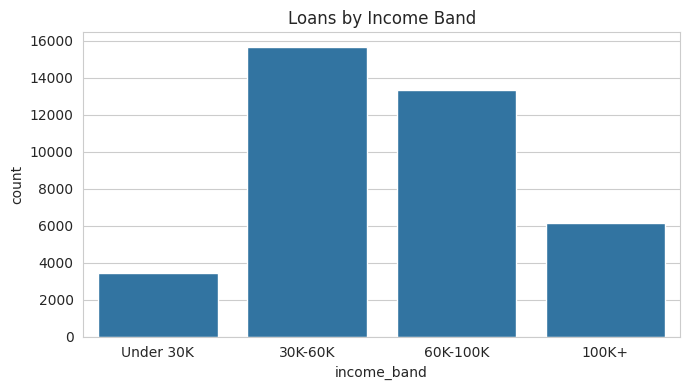

In [31]:
fig, ax = plt.subplots(figsize=(7,4))
sns.countplot(x='income_band', data=df, order=['Under 30K','30K-60K','60K-100K','100K+'], ax=ax)
ax.set_title('Loans by Income Band')
plt.tight_layout()
plt.show()

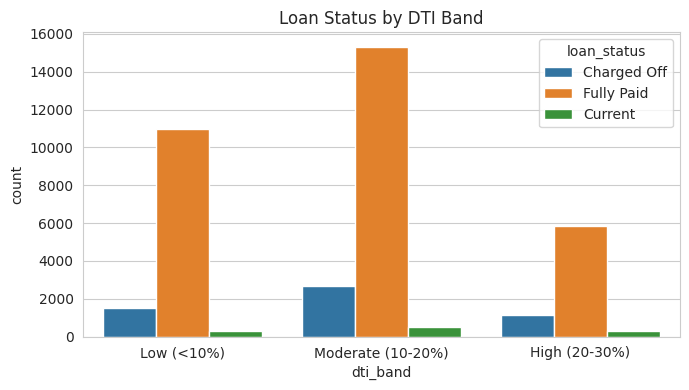

In [32]:
fig, ax = plt.subplots(figsize=(7,4))
sns.countplot(x='dti_band', data=df, order=['Low (<10%)','Moderate (10-20%)','High (20-30%)'], hue='loan_status', ax=ax)
ax.set_title('Loan Status by DTI Band')
plt.tight_layout()
plt.show()

## Repayment ratio and charged off loans
repayment_ratio = total_payment / loan_amount roughly, so under 1 means they haven't fully paid back yet - worth a look at what's dragging it down

In [33]:
df.groupby('loan_status')['repayment_ratio'].describe()

               count      mean       std    min    25%     50%    75%    max
loan_status                                                                 
Charged Off   5333.0  0.575303  0.325452  0.005  0.302  0.5330  0.828  1.582
Current       1098.0  1.293683  0.147152  0.712  1.217  1.2935  1.395  1.658
Fully Paid   32145.0  1.165403  0.130604  0.113  1.104  1.1610  1.222  1.689

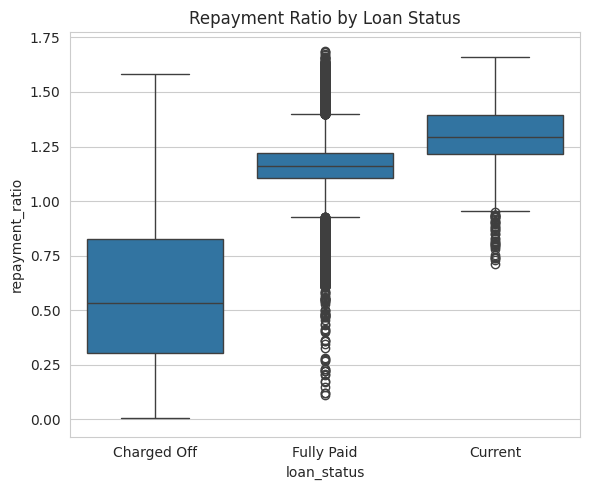

In [34]:
fig, ax = plt.subplots(figsize=(6,5))
sns.boxplot(x='loan_status', y='repayment_ratio', data=df, ax=ax)
ax.set_title('Repayment Ratio by Loan Status')
plt.tight_layout()
plt.show()

In [35]:
charged_off = df[df['loan_status'] == 'Charged Off']
charged_off.groupby('grade')['loan_amount'].agg(['count','mean']).round(2)

       count      mean
grade                 
A        552   8039.40
B       1343  11092.14
C       1266  11184.42
D       1072  12333.54
E        691  15897.43
F        311  19300.16
G         98  18665.56

## Quick summary by grade
last check - avg rate, amount, income per grade, sorted so it reads top to bottom cleanly

In [36]:
df.groupby('grade')[['int_rate','loan_amount','annual_income','dti']].mean().round(2).sort_index()

       int_rate  loan_amount  annual_income    dti
grade                                             
A          7.35      8695.66       67533.99  12.04
B         11.03     11196.16       68320.58  13.43
C         13.55     11064.83       68482.66  13.92
D         15.71     12335.16       69092.81  13.98
E         17.71     15852.51       78328.38  14.10
F         19.74     18395.38       85115.68  14.17
G         21.40     20281.39       94724.94  14.06